# 1. Introduction to Graph-Based Medical Analysis

In this notebook, we explore how to analyze large-scale biomedical literature using graph-based techniques.
We work with the Medline dataset, a massive collection of medical publication metadata provided in XML format.

Each publication is annotated with MeSH (Medical Subject Headings) terms, where some are marked as "Major Topics".
By extracting these terms and examining how they co-occur across documents, we build a topic co-occurrence graph.

This graph allows us to:
- Identify highly central medical topics
- Detect clusters of related research areas
- Analyze connectivity, influence, and structure in biomedical knowledge

We'll use **PySpark** with **GraphFrames** (https://spark-packages.org/package/graphframes/graphframes) and the **Databrick XML Package** (https://docs.databricks.com/aws/en/archive/connectors/spark-xml-library) to build and analyze this graph efficiently at scale.

In [1]:
from pyspark.sql import SparkSession

# Create SparkSession with GraphFrames support
spark = SparkSession.builder \
    .appName("Medline Topic Graph") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.1-s_2.12,com.databricks:spark-xml_2.12:0.15.0") \
    .getOrCreate()

print("Spark session created. Ready to analyze medical topic graphs.")

Spark session created. Ready to analyze medical topic graphs.


# 2. Loading Medline XML into Spark

We begin by loading Medline data files in XML format using the `spark-xml` package.
Each article in the Medline dataset is wrapped inside a `<MedlineCitation>` tag, which we'll use as the root for parsing.

This step parses the structured XML into a Spark DataFrame, making it easier to extract and manipulate elements like titles, authors, journals, and MeSH descriptors.


In [2]:
# Make sure to point this path to your actual Medline XML file(s) or folder
xml_path = "./medline-sample/medsamp2016*.xml"

# Load XML data using the 'spark-xml' library
df = spark.read.format("xml") \
    .option("rowTag", "MedlineCitation") \
    .load(xml_path) #.sample(False, 0.01)

# Display the XML schema to inspect its structure
df.printSchema()

root
 |-- Article: struct (nullable = true)
 |    |-- Abstract: struct (nullable = true)
 |    |    |-- AbstractText: string (nullable = true)
 |    |-- ArticleTitle: string (nullable = true)
 |    |-- AuthorList: struct (nullable = true)
 |    |    |-- Author: array (nullable = true)
 |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |-- AffiliationInfo: struct (nullable = true)
 |    |    |    |    |    |-- Affiliation: string (nullable = true)
 |    |    |    |    |-- CollectiveName: string (nullable = true)
 |    |    |    |    |-- ForeName: string (nullable = true)
 |    |    |    |    |-- Initials: string (nullable = true)
 |    |    |    |    |-- LastName: string (nullable = true)
 |    |    |    |    |-- Suffix: string (nullable = true)
 |    |    |    |    |-- _ValidYN: string (nullable = true)
 |    |    |-- _CompleteYN: string (nullable = true)
 |    |-- Journal: struct (nullable = true)
 |    |    |-- ISOAbbreviation: string (nullable = true)
 | 

In [3]:
df.toPandas()

,Article,ChemicalList,CitationSubset,CommentsCorrectionsList,DateCompleted,DateCreated,DateRevised,KeywordList,MedlineJournalInfo,MeshHeadingList,OtherAbstract,OtherID,PMID,PersonalNameSubjectList,SupplMeshList,_Owner,_Status
0,"(None, Association of maternal and fetal facto...",None,[J],None,"(3, 1, 1980)","(3, 1, 1980)","(19, 2, 2013)","([(N, Behavior), (Y, Comparative Studies), (N,...","(United States, 0002-9955, J Am Med Assoc, 750...","([(Row(_MajorTopicYN='N', _Type=None, _UI='D00...","(Pregnancy, delivery, and neonatal records of ...","[(PIP, 550018), (POP, 00020417)]","(12255379, 1)",None,None,PIP,MEDLINE
1,"(None, Spermicidal activity of undiluted comme...","([(Row(_UI='D003270', _VALUE='Contraceptive Ag...",[J],None,"(3, 1, 1980)","(3, 1, 1980)","(15, 11, 2006)","([(N, Contraception), (N, Contraceptive Agents...","(United States, 0002-9955, J Am Med Assoc, 750...","([(Row(_MajorTopicYN='N', _Type=None, _UI='D00...",(Laboratory tests designed to measure the sper...,"[(PIP, 550062), (POP, 00021014)]","(12255395, 1)",None,None,PIP,MEDLINE
2,"(None, The diagnosis of sex before birth using...",None,[J],None,"(8, 1, 1980)","(8, 1, 1980)","(17, 11, 2011)","([(Y, Amniocentesis), (Y, Clinical Research), ...","(United States, 0578-8994, Bull Res Counc Isr,...","([(Row(_MajorTopicYN='Y', _Type=None, _UI='D00...",(Preliminary results on the diagnosis of sex i...,"[(PIP, 550092), (POP, 00034684)]","(12307916, 1)",None,None,PIP,MEDLINE
3,"(None, Cesarean hysterectomy., ([Row(Affiliati...",None,[J],None,"(3, 1, 1980)","(3, 1, 1980)","(11, 11, 2009)","([(N, Age Factors), (N, Anesthesia), (N, Cesar...","(United States, None, West J Surg Obstet Gynec...","([(Row(_MajorTopicYN='N', _Type=None, _UI='D00...",(This paper reviewed indications for cesarian ...,"[(PIP, 550002), (POP, 00010817)]","(12305195, 1)",None,None,PIP,MEDLINE
4,"(None, Skin., ([Row(AffiliationInfo=None, Coll...",None,[J],None,"(8, 1, 1980)","(8, 1, 1980)","(27, 10, 2009)","([(Y, Animals, Laboratory), (N, Biology), (N, ...","(United States, 0564-1217, Transplant Bull, 21...","([(Row(_MajorTopicYN='Y', _Type=None, _UI='D00...",(A reevaluation of the interpretation of findi...,"[(PIP, 550095), (POP, 00034486)]","(12334405, 1)",None,None,PIP,MEDLINE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,"(None, [Reversal of the Mitsuda test with BCG ...","([(Row(_UI='D001500', _VALUE='BCG Vaccine'), 0...",[OM],None,"(18, 2, 2014)","(1, 12, 1956)","(12, 8, 2014)","([(Y, BCG VACCINATION/effects), (Y, LEPROSY/im...","(Not Available, 0254-4504, Rev Med Dominic, 20...","([(Row(_MajorTopicYN='N', _Type=None, _UI='D00...",None,"[(CLML, 5630:59523)]","(24544065, 1)",None,None,NLM,MEDLINE
29996,"(None, [Social problem of filariasis in our co...",None,[OM],None,"(18, 2, 2014)","(1, 12, 1956)","(12, 8, 2014)","([(Y, FILARIASIS/prevention and control)], NLM)","(Not Available, 0254-4504, Rev Med Dominic, 20...","([(Row(_MajorTopicYN='Y', _Type=None, _UI='D03...",None,"[(CLML, 5630:59524)]","(24544066, 1)",None,None,NLM,MEDLINE
29997,"(None, [Not Available]., ([Row(AffiliationInfo...","([(Row(_UI='D011343', _VALUE='Procaine'), 4Z8Y...",[OM],None,"(18, 2, 2014)","(1, 12, 1956)","(13, 8, 2015)","([(Y, PROCAINE/administration)], NLM)","(Not Available, 0254-4504, Rev Med Dominic, 20...","([(Row(_MajorTopicYN='N', _Type=None, _UI='D00...",None,"[(CLML, 5630:59525)]","(24544067, 1)",None,None,NLM,MEDLINE
29998,"(None, [The country doctor]., ([Row(Affiliatio...",None,[OM],None,"(18, 2, 2014)","(1, 12, 1956)","(12, 8, 2014)","([(Y, PUBLIC HEALTH), (Y, RURAL CONDITIONS)], ...","(Not Available, 0254-4504, Rev Med Dominic, 20...","([(Row(_MajorTopicYN='N', _Type=None, _UI='D00...",None,"[(CLML, 5630:59526)]","(24544068, 1)",None,None,NLM,MEDLINE


# 3. Parsing MeSH Major Topics from XML

Each Medline article is annotated with MeSH (Medical Subject Headings) terms.
We are particularly interested in the `<DescriptorName>` tags that are marked with `MajorTopicYN="Y"`, indicating that the topic is a main focus of the article.

In this step, we:
- Explode the `MeshHeadingList` array
- Filter to keep only the major topics
- Extract the text of each major `DescriptorName`

This gives us a list of major medical topics per article.


In [4]:
from pyspark.sql.functions import explode, col

# Step 1: Explode the array of MeshHeading elements
mesh_df = df.select(explode("MeshHeadingList.MeshHeading").alias("Mesh"))

# Step 2: Filter where DescriptorName._MajorTopicYN == "Y"
major_topic_df = mesh_df.filter(col("Mesh.DescriptorName._MajorTopicYN") == "Y")

# Step 3: Select article ID (if needed) and the DescriptorName value
major_topics_df = major_topic_df.select(col("Mesh.DescriptorName._VALUE").alias("MajorTopic"))

# Show example topics
major_topics_df.show(10, truncate=False)

+----------------------------------+
|MajorTopic                        |
+----------------------------------+
|Intellectual Disability           |
|Maternal-Fetal Exchange           |
|Pregnancy Complications           |
|Pessaries                         |
|Sperm Transport                   |
|Spermatocidal Agents              |
|Vaginal Creams, Foams, and Jellies|
|Amniocentesis                     |
|Research                          |
|Cesarean Section                  |
+----------------------------------+
only showing top 10 rows



# 4. Analyzing Major Topic Frequencies

After extracting the major MeSH topics, we want to understand how frequently each topic appears across the Medline dataset.

This helps us identify:
- The most discussed medical topics
- The distribution of topic popularity (long-tail behavior)

We will:
- Count topic occurrences
- Show the top 10 most frequent topics
- Show statistics of the distribution


In [5]:
from pyspark.sql.functions import desc

# Count how many times each major topic appears
topic_counts = major_topics_df.groupBy("MajorTopic").count()

# Show the top 10 most common major topics
top_topics = topic_counts.orderBy(desc("count"))
top_topics.show(10, truncate=False)

+--------------------------------------+-----+
|MajorTopic                            |count|
+--------------------------------------+-----+
|Disease                               |1202 |
|Neoplasms                             |983  |
|Tuberculosis                          |950  |
|Blood                                 |518  |
|Anesthesia                            |379  |
|Wounds and Injuries                   |370  |
|Medicine                              |322  |
|Nervous System Physiological Phenomena|318  |
|Antibiotics, Antitubercular           |298  |
|Body Fluids                           |284  |
+--------------------------------------+-----+
only showing top 10 rows



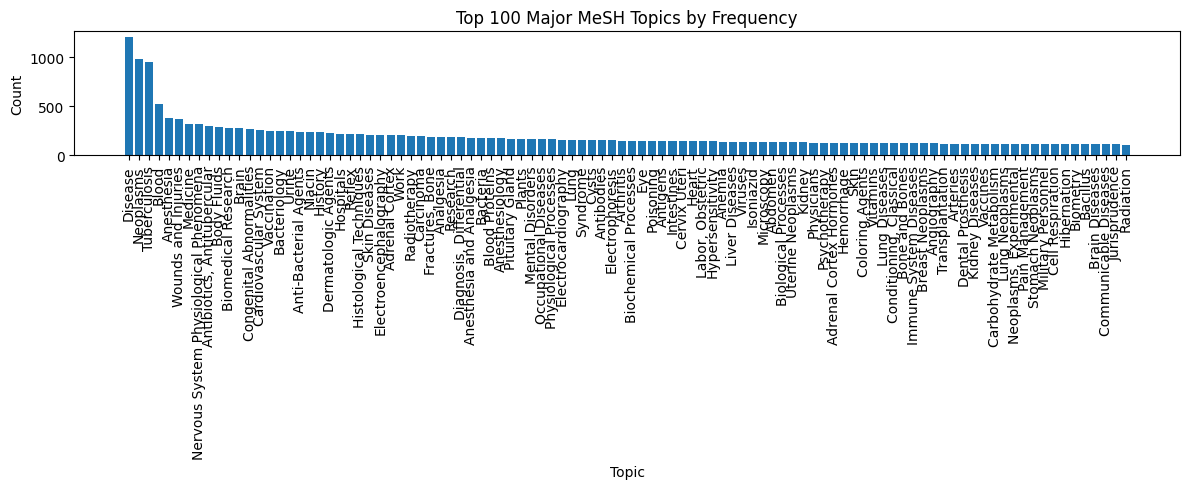

In [6]:
# Convert to pandas for plotting
import matplotlib.pyplot as plt

top_pd = top_topics.limit(100).toPandas()

# Plot a histogram of top 100 topics
plt.figure(figsize=(12, 5))
plt.bar(top_pd['MajorTopic'], top_pd['count'])
plt.xticks(rotation=90)
plt.title("Top 100 Major MeSH Topics by Frequency")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 5. Computing Topic Co-Occurrences

To analyze relationships between major MeSH topics, we compute how often each pair of topics appears together in the same article.

Steps:
- Group major topics by article
- Generate all unique topic pairs for each article (combinations)
- Count frequency of each topic pair across the corpus
- Cache the resulting co-occurrence data for later graph construction


In [7]:
from pyspark.sql.functions import collect_list, size
from itertools import combinations
from pyspark.sql.types import ArrayType, StringType, StructType, StructField

# Step 1: Reload full citations to preserve grouping
# Load article ID along with major topic (you might need to adjust this path based on your structure)
# For now, we assume each row still represents one MedlineCitation

# First, explode MeshHeadings per article to recover article-topic structure
df_with_id = df.withColumn("CitationID", col("PMID._VALUE"))  # or use row_number if PMID not present
mesh_expanded = df_with_id.select("CitationID", explode("MeshHeadingList.MeshHeading").alias("Mesh"))

# Filter to major topics
major_mesh = mesh_expanded.filter(col("Mesh.DescriptorName._MajorTopicYN") == "Y") \
                          .select("CitationID", col("Mesh.DescriptorName._VALUE").alias("Topic"))

# Step 2: Group all topics per article
topics_per_article = major_mesh.groupBy("CitationID").agg(collect_list("Topic").alias("Topics"))

# Step 3: Define a UDF to compute combinations of topic pairs
from pyspark.sql.functions import udf

def get_combinations(topics):
    return list(combinations(sorted(set(topics)), 2)) if len(topics) > 1 else []

pair_udf = udf(get_combinations, ArrayType(ArrayType(StringType())))

# Step 4: Apply UDF to get topic pairs
topic_pairs_df = topics_per_article.withColumn("Pairs", pair_udf("Topics")).select("Pairs")

# Step 5: Explode pairs and count frequency
pair_counts = topic_pairs_df.select(explode("Pairs").alias("topic_pair")) \
    .groupBy("topic_pair").count().cache()

# Show some example topic pairs and their co-occurrence counts
pair_counts.show(10, truncate=False)

+-------------------------------------+-----+
|topic_pair                           |count|
+-------------------------------------+-----+
|[Genitalia, Female, Neoplasms]       |32   |
|[Leukemia, Leukemia, Experimental]   |10   |
|[Genitalia, Female, Vaginal Diseases]|3    |
|[Gingiva, Hyperplasia]               |2    |
|[Personality, Personality Disorders] |48   |
|[Antibodies, Erythrocytes]           |8    |
|[Face, Facial Hemiatrophy]           |1    |
|[Palliative Care, Urogenital System] |1    |
|[Mycobacterium tuberculosis, Niacin] |9    |
|[Anesthesia, Somatoform Disorders]   |1    |
+-------------------------------------+-----+
only showing top 10 rows



# 6. Assigning Unique Topic IDs

Graph algorithms require each vertex (topic) to have a unique numeric ID.

We demonstrate two approaches to assign unique IDs:
- **Option 1**: Use `hashlib.md5()` to hash topic strings into long IDs.
- **Option 2**: Use `zipWithUniqueId()` to assign numeric IDs incrementally.

These IDs will be used as vertex identifiers in the topic co-occurrence graph.


### Option 1: Use hashlib.md5() Hashing

In [8]:
import hashlib
from pyspark.sql.functions import udf
from pyspark.sql.types import LongType

# Define hashing function to convert topic string to long
def hash_topic(topic):
    return int(hashlib.md5(topic.encode('utf-8')).hexdigest()[:16], 16)

hash_udf = udf(hash_topic, LongType())

# Extract all unique topic names from pair_counts
topics_df = pair_counts.selectExpr("topic_pair[0] as topic_name").union(pair_counts.selectExpr("topic_pair[1] as topic_name")).distinct()

# Apply hashing to get unique IDs
hashed_topics = topics_df.withColumn("id", hash_udf("topic_name"))

# Show result
hashed_topics.show(10, truncate=False)

+--------------------+-------------------+
|topic_name          |id                 |
+--------------------+-------------------+
|Alcaligenes faecalis|3633602343728644521|
|Kidney Diseases     |8200508034038853463|
|Arteritis           |39719695582569229  |
|Arsenic             |7730943551945338993|
|Columbidae          |248237651987997761 |
|Biomedical Research |5925526798038442504|
|Hyperthyroidism     |null               |
|Hysterectomy        |3426869519452823720|
|Ganglia             |5039456799860415350|
|Ammonium Compounds  |1375164521857514191|
+--------------------+-------------------+
only showing top 10 rows



### Option 2: Use zipWithUniqueId()

* Each topic gets a clean, sequential numeric ID.

* No NULL values.

* Safe, simple, and ideal for GraphFrames.

In [9]:
# Create RDD of distinct topic names
topics_rdd = topics_df.rdd.map(lambda row: row["topic_name"]).distinct()

# Assign unique numeric IDs using zipWithUniqueId
topic_id_rdd = topics_rdd.zipWithUniqueId()

# Convert to DataFrame
topic_id_df = spark.createDataFrame(topic_id_rdd, ["topic_name", "id"])

# Show result
topic_id_df.show(10, truncate=False)

+--------------------+---+
|topic_name          |id |
+--------------------+---+
|Ganglia             |0  |
|Dogfish             |6  |
|Deficiency Diseases |12 |
|Anesthesia          |18 |
|Personality         |24 |
|Parkinson Disease   |30 |
|Bacteriology        |36 |
|Nutritional Sciences|42 |
|Astacoidea          |48 |
|Ear Diseases        |54 |
+--------------------+---+
only showing top 10 rows



# 7. Creating Graph Vertices and Edges

To build a co-occurrence graph with GraphFrames, we need:
- **Vertices**: a DataFrame of topic IDs and topic names
- **Edges**: a DataFrame of topic ID pairs and the number of times those topics co-occur

These will be used to construct a `GraphFrame(vertices, edges)`.


In [10]:
from pyspark.sql.functions import col

# Option 2: use topic_id_df from zipWithUniqueId (Topic, id)
# Already created in Section 6

# ------------------------------
# STEP 1: Create Vertex DataFrame
# ------------------------------

vertices = topic_id_df.select(col("id").alias("id"), col("topic_name").alias("topic_name"))
vertices.show(5)

# ------------------------------
# STEP 2: Join to get numeric IDs for topic pairs
# ------------------------------

edges_labeled = pair_counts \
    .join(topic_id_df.withColumnRenamed("topic_name", "topic_name1").withColumnRenamed("id", "id1"),
          col("topic_pair")[0] == col("topic_name1")) \
    .join(topic_id_df.withColumnRenamed("topic_name", "topic_name2").withColumnRenamed("id", "id2"),
          col("topic_pair")[1] == col("topic_name2")) \
    .select(col("id1").alias("src"), col("id2").alias("dst"), col("count"))

edges_labeled.show(5)

+---+-------------------+
| id|         topic_name|
+---+-------------------+
|  0|            Ganglia|
|  6|            Dogfish|
| 12|Deficiency Diseases|
| 18|         Anesthesia|
| 24|        Personality|
+---+-------------------+
only showing top 5 rows



+---+----+-----+
|src| dst|count|
+---+----+-----+
|  0| 114|    1|
|  0|2916|    1|
|  0|3734|    1|
|  0|3969|    1|
|  0|4110|    1|
+---+----+-----+
only showing top 5 rows



# 8. Graph Construction with GraphFrames

With our vertices and edges prepared, we now build a `GraphFrame`.

Steps:
- Use `vertices` (with `id`, `name`) and `edges` (with `src`, `dst`, `count`)
- Initialize the graph using `GraphFrame(vertices, edges)`
- Cache the graph to optimize future graph queries


In [11]:
# Import GraphFrames
from graphframes import GraphFrame

# Construct the GraphFrame
topic_graph = GraphFrame(vertices, edges_labeled)

# Cache it for performance
topic_graph.cache()

# Show basic stats
print("Topic-graph has:")
print(" - vertices:", topic_graph.vertices.count())
print(" - edges:", topic_graph.edges.count())

# Display a few vertices and edges
topic_graph.vertices.show(5)
topic_graph.edges.show(5)

Topic-graph has:
 - vertices: 7596


 - edges: 72560
+---+-------------------+
| id|         topic_name|
+---+-------------------+
|  0|            Ganglia|
|  6|            Dogfish|
| 12|Deficiency Diseases|
| 18|         Anesthesia|
| 24|        Personality|
+---+-------------------+
only showing top 5 rows

+----+---+-----+
| src|dst|count|
+----+---+-----+
| 162|236|    2|
|5989|236|    4|
|  16|236|    7|
|3718|236|    1|
|1506|174|    2|
+----+---+-----+
only showing top 5 rows



# 9. Connected Components Analysis

A connected component is a group of topics in the graph where each topic is reachable from any other within that group.

This helps identify tightly connected medical subfields.

Steps:
- Run `graph.connectedComponents()` to find components
- Join results with topic names
- Count and rank components by their sizes


### Connected Components Computation

In [12]:
from pyspark.sql.functions import col
from graphframes import GraphFrame

topic_graph = GraphFrame(vertices, edges_labeled)
spark.sparkContext.setCheckpointDir("/tmp/graphframes-checkpoints")

components = topic_graph.connectedComponents()
components_named = components.alias("comp").join(vertices.alias("vert"), on="id")

components_named.select(col("vert.topic_name").alias("topic_name"), \
                        col("vert.id").alias("topic_id"), \
                        col("comp.component").alias("component_id")) \
                .show(10, truncate=False)

+--------------------+--------+------------+
|topic_name          |topic_id|component_id|
+--------------------+--------+------------+
|Ganglia             |0       |0           |
|Dogfish             |6       |0           |
|Deficiency Diseases |12      |0           |
|Anesthesia          |18      |0           |
|Personality         |24      |0           |
|Parkinson Disease   |30      |0           |
|Bacteriology        |36      |0           |
|Nutritional Sciences|42      |0           |
|Astacoidea          |48      |0           |
|Ear Diseases        |54      |0           |
+--------------------+--------+------------+
only showing top 10 rows



### Analyze Component Sizes

In [13]:
# Count how many topics are in each component
component_sizes = components_named.groupBy("component").count().orderBy(desc("count"))

# Show the largest components
component_sizes.show(10, truncate=False)

+---------+-----+
|component|count|
+---------+-----+
|0        |7572 |
|3064     |3    |
|3010     |3    |
|5518     |2    |
|2664     |2    |
|4248     |2    |
|2652     |2    |
|2959     |2    |
|1248     |2    |
|2176     |2    |
+---------+-----+
only showing top 10 rows



# 10. Degree-Distribution Analysis

The degree of a node (topic) is the number of edges connected to it — a key measure of how central or important a topic is in the network.

We will:
- Compute the degree of each topic using `graph.degrees`
- Join with topic names to see which topics are most connected
- Count how many topics are isolated (singletons) with degree = 0


### Degree Analysis

In [14]:
from pyspark.sql.functions import col, desc

# Compute degrees of all topics (in + out degree for undirected graphs)
degrees = topic_graph.degrees

# Join with topic names
degree_with_names = degrees.join(vertices, on="id")

# Show top 10 most connected topics
degree_with_names.select("topic_name", "id", "degree").orderBy(desc("degree")).show(10, truncate=False)

+---------------------------+----+------+
|topic_name                 |id  |degree|
+---------------------------+----+------+
|Disease                    |1374|1482  |
|Neoplasms                  |2311|918   |
|Blood                      |2375|706   |
|Tuberculosis               |128 |665   |
|Wounds and Injuries        |2782|449   |
|Body Fluids                |6007|396   |
|Brain                      |4859|391   |
|Congenital Abnormalities   |4738|371   |
|Antibiotics, Antitubercular|1192|370   |
|Anesthesia                 |18  |356   |
+---------------------------+----+------+
only showing top 10 rows



### Count Singleton Topics

In [15]:
# Count how many topics have degree = 0 (no connections)
singleton_count = degree_with_names.filter(col("degree") == 0).count()

print(f"Number of singleton (isolated) topics: {singleton_count}")

Number of singleton (isolated) topics: 0


# 11. Filtering Edges with Chi-Square Test

Not all topic co-occurrences are meaningful — some may happen by chance.

We apply a **chi-squared test of independence** to evaluate whether two topics co-occur more often than expected.

Steps:
- Estimate expected co-occurrence frequency under independence
- Compute χ² statistic for each edge
- Filter edges with χ² > 6.63 (significant at p < 0.01)
- Build a new filtered subgraph for further analysis


### Chi-Square Filtering Formula

We approximate the chi-square value using:

$$
\chi^2 = \frac{(O - E)^2}{E}
$$

Where:

- **O**: observed co-occurrence (i.e., edge `count`)
- **E**: expected co-occurrence assuming independence:

$$
E = \frac{\text{deg}(A) \times \text{deg}(B)}{N}
$$

- **N**: total number of edges in the graph


### Compute Chi-Square Statistic and Filter Edges

In [16]:
from pyspark.sql.functions import log, col, broadcast

# Get degrees of each topic (we'll need them for expected counts)
deg = topic_graph.degrees.withColumnRenamed("id", "topic_id").withColumnRenamed("degree", "deg")

# Total number of edges
N = topic_graph.edges.count()

# Join edge table with degrees of both src and dst
edges_deg = topic_graph.edges \
    .join(broadcast(deg), topic_graph.edges.src == deg.topic_id, "left") \
    .withColumnRenamed("deg", "deg_src") \
    .drop("topic_id") \
    .join(broadcast(deg), topic_graph.edges.dst == deg.topic_id, "left") \
    .withColumnRenamed("deg", "deg_dst") \
    .drop("topic_id")

# Compute expected count and chi-square statistic
edges_scored = edges_deg.withColumn("expected", (col("deg_src") * col("deg_dst")) / N) \
                        .withColumn("chi2", ((col("count") - col("expected"))**2) / col("expected"))

# Filter edges with chi2 > 6.63 (significant at p < 0.01, 1 degree of freedom)
significant_edges = edges_scored.filter(col("chi2") > 6.63)

# Show filtered edges
significant_edges.select("src", "dst", "count", "chi2").orderBy(col("chi2").desc()).show(10, truncate=False)

+----+----+-----+------------------+
|src |dst |count|chi2              |
+----+----+-----+------------------+
|4248|7483|2    |290236.0000137817 |
|391 |408 |91   |196824.38957516223|
|5603|3353|15   |151136.66815509007|
|391 |3968|76   |137260.0289194245 |
|408 |3968|81   |127778.43289954257|
|6856|4854|17   |124047.8958202312 |
|6857|4695|7    |98748.22271836335 |
|79  |5902|71   |79984.01253009934 |
|2859|2579|26   |78428.90461356119 |
|2959|3346|1    |72558.00001378168 |
+----+----+-----+------------------+
only showing top 10 rows



### Build Filtered Subgraph

In [17]:
# Reconstruct graph using significant edges only
filtered_graph = GraphFrame(vertices, significant_edges.select("src", "dst", "count"))
filtered_graph.cache()

print("Filtered-graph has:")
print(" - vertices:", filtered_graph.vertices.count())
print(" - edges:", filtered_graph.edges.count())

Filtered-graph has:


25/05/09 17:21:36 WARN CacheManager: Asked to cache already cached data.


 - vertices: 7596


 - edges: 60331


# 12. Re-run Component and Degree Analysis on Filtered Graph

After filtering edges based on chi-square significance, we now examine how the graph structure has changed.

We will:
- Re-run `connectedComponents()` to find new clusters
- Recompute degree distribution
- Identify how many topics are now isolated (degree = 0) or in small disconnected groups


### Connected Components on Filtered Graph

In [18]:
# Re-run connected components on filtered graph
spark.sparkContext.setCheckpointDir("/tmp/graphframes-checkpoints")

filtered_components = filtered_graph.connectedComponents()

# Join with topic names
filtered_components_named = filtered_components.alias("comp").join(vertices.alias("vert"), on="id")

# Show example components
filtered_components_named.select(col("vert.topic_name").alias("topic_name"), \
                                 col("vert.id").alias("topic_id"), \
                                 col("comp.component").alias("component_id")) \
                            .show(10, truncate=False)

+--------------------+--------+------------+
|topic_name          |topic_id|component_id|
+--------------------+--------+------------+
|Ganglia             |0       |0           |
|Dogfish             |6       |0           |
|Deficiency Diseases |12      |0           |
|Anesthesia          |18      |0           |
|Personality         |24      |0           |
|Parkinson Disease   |30      |0           |
|Bacteriology        |36      |0           |
|Nutritional Sciences|42      |0           |
|Astacoidea          |48      |0           |
|Ear Diseases        |54      |0           |
+--------------------+--------+------------+
only showing top 10 rows



### Count Sizes of Components

In [19]:
# Count number of topics in each connected component
filtered_component_sizes = filtered_components_named.groupBy("component").count().orderBy(desc("count"))
filtered_component_sizes.show(10, truncate=False)

+---------+-----+
|component|count|
+---------+-----+
|0        |7572 |
|3064     |3    |
|3010     |3    |
|5518     |2    |
|2664     |2    |
|4248     |2    |
|2652     |2    |
|2959     |2    |
|1248     |2    |
|2176     |2    |
+---------+-----+
only showing top 10 rows



### Degree Analysis on Filtered Graph

In [20]:
# Recompute degrees
filtered_degrees = filtered_graph.degrees
filtered_degrees_named = filtered_degrees.join(vertices, on="id")

# Show top 10 most connected topics
filtered_degrees_named.select("topic_name", "id", "degree").orderBy(desc("degree")).show(10, truncate=False)

+------------------------+----+------+
|topic_name              |id  |degree|
+------------------------+----+------+
|Disease                 |1374|519   |
|Neoplasms               |2311|468   |
|Blood                   |2375|280   |
|Tuberculosis            |128 |262   |
|Anesthesia              |18  |226   |
|Bacteriology            |36  |214   |
|Congenital Abnormalities|4738|209   |
|Wounds and Injuries     |2782|207   |
|Plants                  |5951|201   |
|Brain                   |4859|195   |
+------------------------+----+------+
only showing top 10 rows



### Count Singleton Topics (degree = 0)

In [21]:
singleton_filtered = filtered_degrees_named.filter(col("degree") == 0).count()
print(f"Number of singleton (disconnected) topics in filtered graph: {singleton_filtered}")

Number of singleton (disconnected) topics in filtered graph: 0


# 13. Triangles and Clustering Coefficients

Triangle counting is a key measure in network analysis that captures local clustering:
- A **triangle** exists when three nodes are all connected to each other.
- The **clustering coefficient** of a node measures how close its neighbors are to forming a complete clique.

We'll use `graph.triangleCount()` to:
- Count how many triangles each node participates in
- Estimate local clustering


In [22]:
# Triangle counting
triangle_counts = filtered_graph.triangleCount()

# Join with vertices, renaming to avoid ambiguity
triangles_named = triangle_counts.join(
    vertices.select(col("id").alias("v_id"), col("topic_name").alias("v_topic_name")),
    triangle_counts.id == col("v_id")
)

# Show top topics by triangle participation
triangles_named.select("topic_name", "id", "count").orderBy(desc("count")).show(10, truncate=False)

+------------------------+----+-----+
|topic_name              |id  |count|
+------------------------+----+-----+
|Neoplasms               |2311|2470 |
|Disease                 |1374|2221 |
|Anesthesia              |18  |1148 |
|Analgesia               |3744|876  |
|Anesthesia and Analgesia|118 |871  |
|Tuberculosis            |128 |843  |
|Blood                   |2375|777  |
|Medicine                |4717|769  |
|Bacteriology            |36  |765  |
|Fractures, Bone         |2552|576  |
+------------------------+----+-----+
only showing top 10 rows



# 14. Approximate Average Path Length (via Shortest-Paths)

The Python API of Pregel in GraphFrames is extremely cumbersome to use for complex datatypes such as dictionaries.
Thus, to estimate the average shortest-path length in our filtered topic graph, we:
- Sample a small set (e.g., 25) of landmark vertices with highest in-/out-degree
- Run GraphFrames' `shortestPaths()` search from all vertices to these landmarks
- Print the average of the vertices' distances to the landmarks
- Visualize the distribution of shortest path lengths

This gives us a sense of how tightly connected the network is.


### Select the Landmark Vertices & Run Shortest-Paths

In [23]:
# Select the top-25 landmark vertices with highest degree
landmarks = [row["id"] for row in filtered_degrees.orderBy(desc("degree")).collect()[:25]]

# Compute the shortest paths using GraphFrames built-in function
shortest_paths = filtered_graph.shortestPaths(landmarks)
shortest_paths.select("id", "distances").show()

# Extract the individual and total path lengths from the rows
path_lengths = []
total_length = 0
for result in shortest_paths.collect():
    for length in result["distances"].values():
        path_lengths.append(length)
        total_length += length
        
print("Average path length:", total_length/len(path_lengths))

+----+--------------------+
|  id|           distances|
+----+--------------------+
|1110|                  {}|
|5724|{1475 -> 3, 2782 ...|
|7002|{1475 -> 3, 1228 ...|
|1410|{1475 -> 3, 2782 ...|
|3456|                  {}|
|3702|                  {}|
|3066|{1475 -> 3, 1228 ...|
|7332|                  {}|
|4038|{1475 -> 4, 2782 ...|
|4374|{1475 -> 4, 3517 ...|
|4890|{1475 -> 3, 1228 ...|
|4014|{1475 -> 3, 2782 ...|
|7020|{1475 -> 3, 2782 ...|
|4926|{1475 -> 2, 1228 ...|
|6156|{1475 -> 3, 2782 ...|
|4476|{1475 -> 3, 2782 ...|
| 912|{1475 -> 3, 2782 ...|
|1338|{1475 -> 3, 1228 ...|
|1494|{1475 -> 3, 2782 ...|
|2958|{1475 -> 4, 2782 ...|
+----+--------------------+
only showing top 20 rows

Average path length: 3.1783493132935994


### Plot the Path-Length Distribution

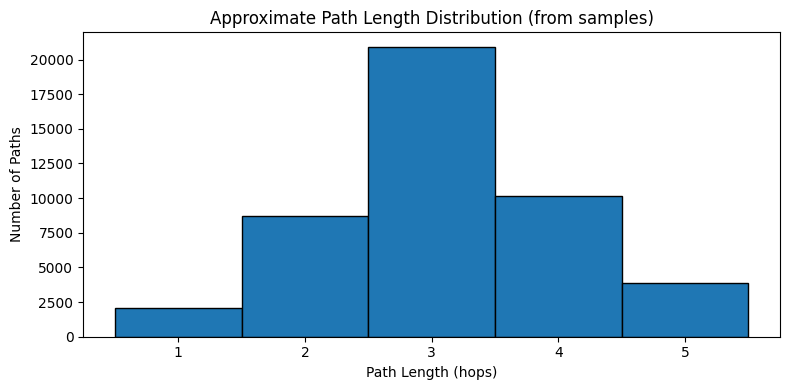

In [24]:
# Plot histogram of path lengths
plt.figure(figsize=(8, 4))
plt.hist(path_lengths, bins=range(1, 7), edgecolor='black', align='left')
plt.title("Approximate Path Length Distribution (from samples)")
plt.xlabel("Path Length (hops)")
plt.ylabel("Number of Paths")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

# 15. PageRank

PageRank measures the influence of a node in a network based on the number and quality of its connections.

In the context of medical topics:
- A high PageRank suggests the topic frequently co-occurs with many other highly connected topics.
- We use GraphFrames' built-in `pageRank()` method with a fixed number of iterations.

We'll display the top-ranked medical topics.


In [25]:
# Run PageRank on the filtered graph
pagerank = filtered_graph.pageRank(resetProbability=0.15, maxIter=10)

# Join with topic names, renaming to avoid ambiguity
pagerank_named = pagerank.vertices.join(
    vertices.select(col("id").alias("v_id"), col("topic_name").alias("v_topic_name")),
    pagerank.vertices.id == col("v_id")
)

# Show top topics by PageRank score
pagerank_named.select("topic_name", "id", "pagerank").orderBy(desc("pagerank")).show(10, truncate=False)

+---------------------+----+------------------+
|topic_name           |id  |pagerank          |
+---------------------+----+------------------+
|Wounds and Injuries  |2782|109.63373443571048|
|Viruses              |878 |52.575651077311086|
|Yersinia Infections  |1206|50.36282674433884 |
|Workers' Compensation|6543|46.05457694721099 |
|Wrist Joint          |5901|44.59450145792707 |
|Vitamins             |6969|38.88809887048178 |
|Work                 |2103|35.08368256646596 |
|Tuberculosis         |128 |33.66255516961148 |
|Wrist Injuries       |4387|33.09790327665049 |
|Vaccination          |1475|32.006849768041754|
+---------------------+----+------------------+
only showing top 10 rows



# 16. Summary

In this notebook, we performed a comprehensive graph-based analysis of biomedical topics using MeSH data from Medline XML:

### 🔍 Key Steps:
- **Parsed XML** data and extracted major MeSH topics per article
- **Computed co-occurrence frequencies** to build a topic graph
- **Assigned unique numeric IDs** to all topics
- **Constructed a GraphFrame** to represent topic relationships
- **Filtered edges** using chi-squared statistics to retain significant topic associations
- **Analyzed structural properties**:
  - Connected components
  - Degree distribution
  - Triangle counts
  - Approximate path lengths via BFS
- **Identified influential topics** using PageRank

### 📈 Key Insights:
- The topic network exhibits a **long-tail distribution**, with a few highly connected topics and many rare ones
- After statistical filtering, the graph retains meaningful relationships but becomes sparser
- Central topics (by degree and PageRank) include those that frequently co-occur with diverse medical terms
- Triangle and clustering analysis revealed topic clusters and tightly-knit domains

This graph approach offers scalable and interpretable insights into how medical concepts relate across scientific literature.
